# 01 - Data Inspection and Subset Construction

In [11]:
import os
import sys
from pathlib import Path

_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from config import SEED, RAW_DIR, PROCESSED_DIR, FIGURES_DIR

## 1 - Load metadata and inspect class distribution

In [12]:
csv_path = RAW_DIR / "HAM10000_metadata.csv"
meta = pd.read_csv(csv_path)

print(f"Total rows: {len(meta)}")
print(f"Columns   : {list(meta.columns)}\n")

dist = meta["dx"].value_counts()
print("Full class distribution (dx):")
print(dist.to_string())
print(f"\nClass fractions:\n{(dist / dist.sum()).round(3).to_string()}")

Total rows: 10015
Columns   : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']

Full class distribution (dx):
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115

Class fractions:
dx
nv       0.669
mel      0.111
bkl      0.110
bcc      0.051
akiec    0.033
vasc     0.014
df       0.011


## 2 - Binary mapping: melanoma vs. benign

- `label = 1` → melanoma (`dx == "mel"`)  ← positive class
- `label = 0` → benign   (`dx ∈ {nv, bkl, df, vasc}`)  ← negative class

The negative class groups the four clinically benign HAM10000 categories:
`nv`, `bkl`, `df` and `vasc`.

We exclude `bcc` and `akiec`because they are other malignant skin cancers.

In [13]:
binary = meta[meta["dx"].isin(["mel", "nv", "bkl", "df", "vasc"])].copy()
binary["label"] = (binary["dx"] == "mel").astype(int)

print("After binary filtering (melanoma vs benign):")
print(binary["dx"].value_counts().to_string())
print(f"\nExcluded malignant classes (bcc, akiec): "
      f"{int(meta['dx'].isin(['bcc', 'akiec']).sum())} rows")
print(f"Total rows kept: {len(binary)}")

After binary filtering (melanoma vs benign):
dx
nv      6705
mel     1113
bkl     1099
vasc     142
df       115

Excluded malignant classes (bcc, akiec): 841 rows
Total rows kept: 9174


## 3 - Class-balanced subset

We keep all melanoma images and randomly sample an equal number of benign images from the combined `nv`+`bkl`+`df`+`vasc` pool.  

In [14]:
mel_df    = binary[binary["label"] == 1]
benign_df = binary[binary["label"] == 0]

n_mel = len(mel_df)
benign_sampled = benign_df.sample(n=n_mel, random_state=SEED)

balanced = pd.concat([mel_df, benign_sampled]).reset_index(drop=True)

print(f"Melanoma rows : {n_mel}")
print(f"Benign rows   : {len(benign_sampled)}")
print("Benign subtype composition of the sample:")
print(benign_sampled["dx"].value_counts().to_string())
print(f"Total balanced: {len(balanced)}")

Melanoma rows : 1113
Benign rows   : 1113
Benign subtype composition of the sample:
dx
nv      921
bkl     159
vasc     18
df       15
Total balanced: 2226


## 4 - Resolve image paths

So the rest of the pipeline works regardless of the exact folder layout.

In [15]:
image_index = {p.stem: p for p in RAW_DIR.rglob("*.jpg")}
print(f"Total .jpg files found under data/raw/: {len(image_index)}")

def resolve_path(image_id):
    p = image_index.get(image_id)
    return str(p) if p is not None else None

balanced["image_path"] = balanced["image_id"].apply(resolve_path)

missing = balanced["image_path"].isna().sum()
print(f"Images not found: {missing} / {len(balanced)}")
if missing > 0:
    print("Missing image_ids:", balanced.loc[balanced["image_path"].isna(), "image_id"].tolist())

Total .jpg files found under data/raw/: 10015
Images not found: 0 / 2226


## 5 - Save balanced subset to CSV

In [16]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out_path = PROCESSED_DIR / "balanced_subset.csv"
balanced.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

Saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\data\processed\balanced_subset.csv


## 6 - Visual sanity check


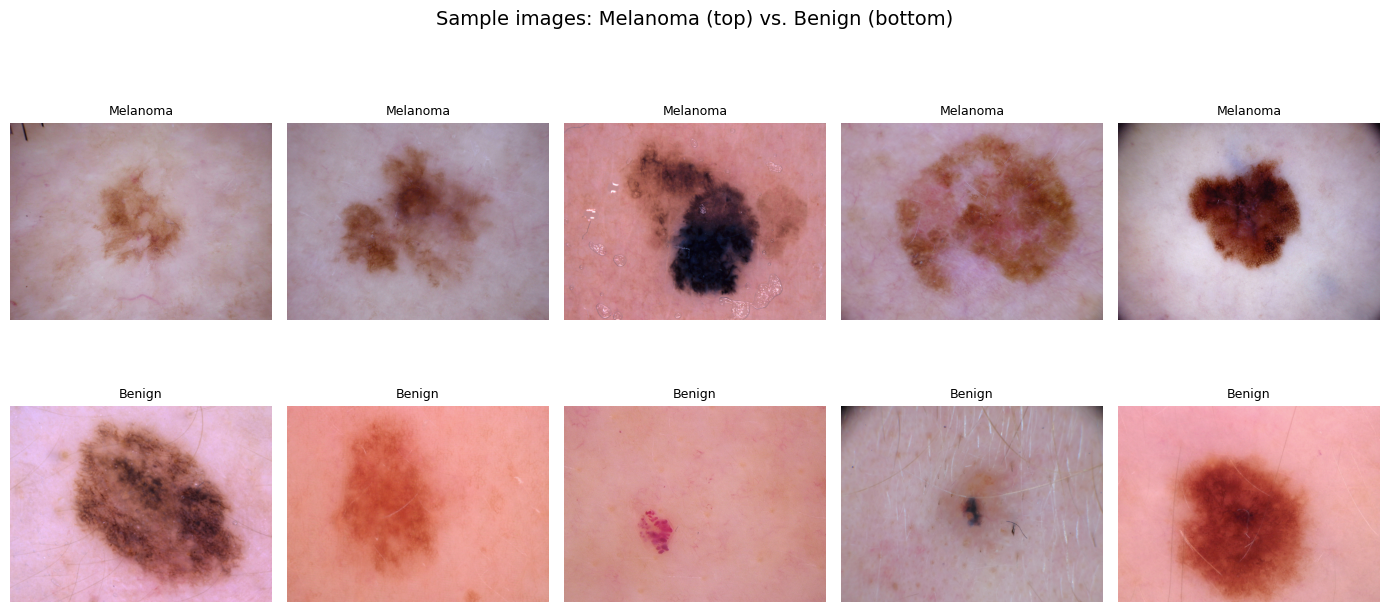

Figure saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\figures\sample_classes.png


In [17]:
rng = np.random.default_rng(SEED)

def sample_paths(df, label, n=5):
    subset = df[(df["label"] == label) & df["image_path"].notna()]
    idx = rng.choice(len(subset), size=min(n, len(subset)), replace=False)
    return subset.iloc[idx]["image_path"].tolist()

mel_paths    = sample_paths(balanced, label=1, n=5)
benign_paths = sample_paths(balanced, label=0, n=5)

fig, axes = plt.subplots(2, 5, figsize=(14, 7))
fig.suptitle("Sample images: Melanoma (top) vs. Benign (bottom)", fontsize=14)

for col, path in enumerate(mel_paths):
    axes[0, col].imshow(mpimg.imread(path))
    axes[0, col].set_title("Melanoma", fontsize=9)
    axes[0, col].axis("off")

for col, path in enumerate(benign_paths):
    axes[1, col].imshow(mpimg.imread(path))
    axes[1, col].set_title("Benign", fontsize=9)
    axes[1, col].axis("off")

plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "sample_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'sample_classes.png'}")

## 7 - Summary

In [18]:
counts = balanced["label"].value_counts().sort_index()
print("Final class counts in balanced_subset.csv:")
print(f"  label=0 (benign)   : {counts[0]}")
print(f"  label=1 (melanoma) : {counts[1]}")
print(f"  Total              : {len(balanced)}")
print(f"\nImages with resolved path: {balanced['image_path'].notna().sum()} / {len(balanced)}")

Final class counts in balanced_subset.csv:
  label=0 (benign)   : 1113
  label=1 (melanoma) : 1113
  Total              : 2226

Images with resolved path: 2226 / 2226
